# Hallucination Detection Baseline Evaluation

This notebook evaluates two baseline methods for detecting hallucinations in tool-augmented LLM responses using the dataset generated in `dataset_generation.ipynb`.

**Data mapping:**
- **Question** → `query` (user's original request)
- **Context** → `context` (tool API output + available tools list)
- **Answer** → `output` (model's final natural-language response)

**Methods evaluated:**
1. **LettuceDetect** ([arXiv:2502.17125](https://arxiv.org/pdf/2502.17125)) — ModernBERT-based token classification model trained to label hallucinated spans in the answer.
2. **LookBackLens** ([arXiv:2407.07071](https://arxiv.org/abs/2407.07071)) — Measures the *lookback ratio* (how much attention the LLM pays to the context vs. its own prior generated tokens) as a hallucination signal, then applies a classifier on those ratios.

**Expected output (as shown in the assignment):**
```
Question: Help me check the weather in Beijing
Context: {weather: "rainy"}
Answer: The weather is sunny.

Token probabilities: The [0.01] weather [0.01] is [0.02] sunny [0.95] . [0.01]
```

In [114]:
# Install additional packages not yet in the environment
%pip install lettucedetect scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Load Dataset

In [115]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

DATA_DIR = Path("datasets")
CORRUPTION_FILES = {
    "tool_output_contradiction": DATA_DIR / "tool_output_contradiction_dataset.jsonl",
    "overgeneration": DATA_DIR / "overgeneration_dataset.jsonl",
    "missing_tool": DATA_DIR / "missing_tool_dataset.jsonl",
}

seed = 1241


def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


dataset = load_jsonl(DATA_DIR / "hallucinations_dataset.jsonl")
print(f"Clean samples: {len(dataset)}")

corrupted_datasets = {name: load_jsonl(path) for name, path in CORRUPTION_FILES.items()}
for name, rows in corrupted_datasets.items():
    n_hall = sum(1 for r in rows if r.get("hallucination_labels"))
    print(f"{name}: {len(rows)} rows, {n_hall} hallucinated ({n_hall / len(rows):.1%})")

# Build combined benchmark — each original example appears 4 times (clean + 3 corruption types)
benchmark_rows = []
for idx, row in enumerate(dataset):
    benchmark_rows.append({
        "example_id": idx,
        "query": row["query"],
        "context": row["context"],
        "output": row["output"],
        "label": 0,
        "corruption_type": "clean",
        "hallucination_labels": [],
    })
for corruption_type, rows in corrupted_datasets.items():
    for idx, row in enumerate(rows):
        label = int(len(row.get("hallucination_labels", [])) > 0)
        benchmark_rows.append({
            "example_id": idx,
            "query": row["query"],
            "context": row["context"],
            "output": row["output"],
            "label": label,
            "corruption_type": corruption_type,
            "hallucination_labels": row.get("hallucination_labels", []),
        })

benchmark_df = pd.DataFrame(benchmark_rows).reset_index(drop=True)

# Grouped train/test split by example_id — prevents leakage across corruption variants
all_example_ids = sorted(benchmark_df["example_id"].unique())
train_ids, test_ids = train_test_split(all_example_ids, test_size=0.2, random_state=seed)
train_df = benchmark_df[benchmark_df["example_id"].isin(train_ids)].reset_index(drop=True)
test_df  = benchmark_df[benchmark_df["example_id"].isin(test_ids)].reset_index(drop=True)

print(f"\nCombined benchmark : {len(benchmark_df)} samples")
print(f"Train rows         : {len(train_df)}  ({len(train_df) / len(benchmark_df):.0%})")
print(f"Test rows          : {len(test_df)}   ({len(test_df) / len(benchmark_df):.0%})")
print(f"Leakage check      : {len(set(train_ids) & set(test_ids))} overlapping example_ids")
display(benchmark_df.groupby(["corruption_type", "label"]).size().rename("count").reset_index())

Clean samples: 1034
tool_output_contradiction: 1034 rows, 1034 hallucinated (100.0%)
overgeneration: 1034 rows, 519 hallucinated (50.2%)
missing_tool: 1034 rows, 519 hallucinated (50.2%)

Combined benchmark : 4136 samples
Train rows         : 3308  (80%)
Test rows          : 828   (20%)
Leakage check      : 0 overlapping example_ids


,corruption_type,label,count
0,clean,0,1034
1,missing_tool,0,515
2,missing_tool,1,519
3,overgeneration,0,515
4,overgeneration,1,519
5,tool_output_contradiction,1,1034


---
## 2. LettuceDetect

**LettuceDetect** (KR Labs, 2025) is a token-classification model built on ModernBERT. Given a (question, context, answer) triple it assigns each answer token a hallucination probability.

- **Model**: `KRLabsOrg/lettuce-detect-base-v2` (or `-large-v2`)
- **Input**: question, list of context passages, answer
- **Output**: per-token hallucination scores + hallucinated spans

Reference: https://arxiv.org/pdf/2502.17125

In [116]:
from lettucedetect.models.inference import HallucinationDetector

MODEL_PATH = "KRLabsOrg/lettucedect-base-modernbert-en-v1"

print(f"Loading LettuceDetect model: {MODEL_PATH} ...")
lettuce_detector = HallucinationDetector(
    method="transformer",
    model_path=MODEL_PATH,
)
print("Model loaded.")

Loading LettuceDetect model: KRLabsOrg/lettucedect-base-modernbert-en-v1 ...


Loading weights: 100%|██████████| 138/138 [00:00<00:00, 4056.76it/s]


Model loaded.


### 2.1 Single-sample walkthrough

In [117]:
sample = dataset[0]

# --- Span-level predictions ---
span_preds = lettuce_detector.predict(
    context=[sample["context"]],
    question=sample["query"],
    answer=sample["output"],
    output_format="spans",
)

print("=== LettuceDetect — Example ===")
print(f"Question : {sample['query'][:100]}...")
print(f"Context  : {sample['context'][:100]}...")
print(f"Answer   : {sample['output'][:200]}...")
print()
if span_preds:
    print("Hallucinated spans detected:")
    for sp in span_preds:
        print(f"  Span: '{sp['span']}' | Score: {sp['score']:.4f}")
else:
    print("No hallucinated spans detected.")

=== LettuceDetect — Example ===
Question : I'm considering investing and I'd like to know what's happening in the market right now. Could you g...
Context  : Market Trends API: {"trends": [{"name": "S&P 500", "description": "Standard & Poor's 500 Index is a ...
Answer   : Here are the top Market Trends in the US right now:

1. **S&P 500**: The Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies. Its cu...

No hallucinated spans detected.


In [118]:
# --- Token-level predictions (matches the required output format) ---
token_preds = lettuce_detector.predict(
    context=[sample["context"]],
    question=sample["query"],
    answer=sample["output"],
    output_format="tokens",
)

def format_token_probabilities(token_preds, max_tokens: int = 40) -> str:
    """Format token predictions as: The [0.01] weather [0.01] is [0.02] ..."""
    parts = []
    for tp in token_preds[:max_tokens]:
        token = tp.get("token", tp.get("word", "?"))
        score = tp.get("score", tp.get("hallucination_score", tp.get("probability", 0.0)))
        parts.append(f"{token} [{score:.2f}]")
    suffix = " ..." if len(token_preds) > max_tokens else ""
    return "Token probabilities: " + " ".join(parts) + suffix

print(format_token_probabilities(token_preds))

Token probabilities: Here [0.00]  are [0.00]  the [0.00]  top [0.00]  Market [0.00]  T [0.00] rends [0.00]  in [0.00]  the [0.00]  US [0.00]  right [0.00]  now [0.00] : [0.00] 
 [0.00] 
 [0.00] 1 [0.00] . [0.00]  ** [0.00] S [0.00] & [0.00] P [0.00]  500 [0.00] **: [0.00]  The [0.00]  Standard [0.00]  & [0.00]  Poor [0.00] 's [0.00]  500 [0.00]  Index [0.00]  is [0.00]  a [0.00]  market [0.00] - [0.00] capital [0.00] ization [0.00] - [0.00] weighted [0.00]  index [0.00]  of [0.00] ...


### 2.2 Batch evaluation

In [119]:
from tqdm.auto import tqdm

# ── Feature extraction: train set ─────────────────────────────────────────────
lettuce_train_feats = []
for _, item in tqdm(train_df.iterrows(), total=len(train_df), desc="LettuceDetect train"):
    try:
        spans = lettuce_detector.predict(
            context=[item["context"]],
            question=item["query"],
            answer=item["output"],
            output_format="spans",
        )
        max_score = max((s["score"] for s in spans), default=0.0)
        n_spans = len(spans)
    except Exception:
        max_score, n_spans = 0.0, 0
    lettuce_train_feats.append({"max_score": max_score, "n_spans": n_spans})

lettuce_train_X = pd.DataFrame(lettuce_train_feats)
lettuce_y_train = train_df["label"].to_numpy()

# ── Train classifier ───────────────────────────────────────────────────────────
lettuce_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lettuce_clf.fit(lettuce_train_X, lettuce_y_train)
print(f"LettuceDetect classifier trained on {len(lettuce_train_X)} samples.")

# ── Feature extraction + predict: test set ────────────────────────────────────
lettuce_test_results = []
lettuce_test_feats = []
for _, item in tqdm(test_df.iterrows(), total=len(test_df), desc="LettuceDetect test"):
    try:
        spans = lettuce_detector.predict(
            context=[item["context"]],
            question=item["query"],
            answer=item["output"],
            output_format="spans",
        )
        max_score = max((s["score"] for s in spans), default=0.0)
        n_spans = len(spans)
    except Exception:
        spans, max_score, n_spans = [], 0.0, 0
    lettuce_test_results.append({
        "query": item["query"][:60] + "...",
        "label": item["label"],
        "corruption_type": item["corruption_type"],
        "max_hallucination_score": max_score,
        "num_hallucinated_spans": n_spans,
        "spans": spans,
    })
    lettuce_test_feats.append({"max_score": max_score, "n_spans": n_spans})

lettuce_test_X = pd.DataFrame(lettuce_test_feats)
lettuce_test_pred  = lettuce_clf.predict(lettuce_test_X)
lettuce_test_score = lettuce_clf.predict_proba(lettuce_test_X)[:, 1]

df_lettuce = pd.DataFrame(lettuce_test_results)
df_lettuce["predicted_hallucination"] = lettuce_test_pred
df_lettuce["lettuce_score"] = lettuce_test_score

y_true_l = df_lettuce["label"].values
y_pred_l  = df_lettuce["predicted_hallucination"].values

print(f"\nLettuceDetect — Test results ({len(df_lettuce)} samples, trained on {len(train_df)}):")
print(f"  Accuracy  : {accuracy_score(y_true_l, y_pred_l):.3f}")
print(f"  Precision : {precision_score(y_true_l, y_pred_l, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_true_l, y_pred_l, zero_division=0):.3f}")
print(f"  F1        : {f1_score(y_true_l, y_pred_l, zero_division=0):.3f}")

LettuceDetect train: 100%|██████████| 3308/3308 [04:18<00:00, 12.81it/s]


LettuceDetect classifier trained on 3308 samples.


LettuceDetect test: 100%|██████████| 828/828 [01:00<00:00, 13.80it/s]



LettuceDetect — Test results (828 samples, trained on 3308):
  Accuracy  : 0.460
  Precision : 0.460
  Recall    : 1.000
  F1        : 0.630


In [120]:
print("=== LettuceDetect — Metrics by Corruption Type ===")
for ctype, sub in df_lettuce.groupby("corruption_type"):
    yt = sub["label"].values
    yp = sub["predicted_hallucination"].values
    print(
        f"  {ctype:<28} "
        f"acc={accuracy_score(yt, yp):.3f}  "
        f"prec={precision_score(yt, yp, zero_division=0):.3f}  "
        f"rec={recall_score(yt, yp, zero_division=0):.3f}  "
        f"f1={f1_score(yt, yp, zero_division=0):.3f}"
    )

display(
    df_lettuce[["query", "label", "corruption_type",
                "predicted_hallucination", "max_hallucination_score"]].head(10)
)
print("\nValue counts — predicted_hallucination:")
display(df_lettuce["predicted_hallucination"].value_counts())

=== LettuceDetect — Metrics by Corruption Type ===
  clean                        acc=0.000  prec=0.000  rec=0.000  f1=0.000
  missing_tool                 acc=0.420  prec=0.420  rec=1.000  f1=0.592
  overgeneration               acc=0.420  prec=0.420  rec=1.000  f1=0.592
  tool_output_contradiction    acc=1.000  prec=1.000  rec=1.000  f1=1.000


,query,label,corruption_type,predicted_hallucination,max_hallucination_score
0,It's fascinating how languages shape our commu...,0,clean,1,0.0
1,Could you please provide me with the current t...,0,clean,1,0.0
2,Given the volatile nature of the crypto market...,0,clean,1,0.0
3,Could you show me the latest Instagram posts f...,0,clean,1,0.0
4,"Oh, that's great to know. Now that the serious...",0,clean,1,0.0
5,Can you please provide the ROA ratio for the c...,0,clean,1,0.0
6,"Hey, could you get me a list of all the tags i...",0,clean,1,0.0
7,It's like a jungle out there and I'm just tryi...,0,clean,1,0.0
8,"Hey, I'm preparing for our next social media c...",0,clean,1,0.0
9,Could you provide me with the top players' sta...,0,clean,1,0.0



Value counts — predicted_hallucination:


predicted_hallucination
1    828
Name: count, dtype: int64

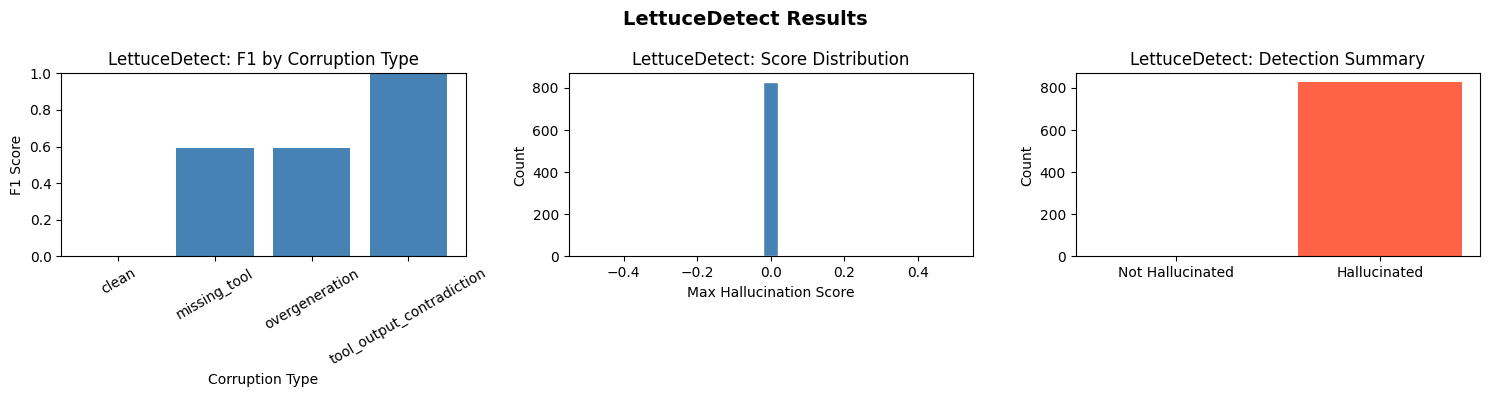

In [121]:
import matplotlib.pyplot as plt

types = sorted(df_lettuce["corruption_type"].unique())
f1_by_type = {
    ct: f1_score(
        df_lettuce[df_lettuce["corruption_type"] == ct]["label"],
        df_lettuce[df_lettuce["corruption_type"] == ct]["predicted_hallucination"],
        zero_division=0,
    )
    for ct in types
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(f1_by_type.keys(), f1_by_type.values(), color="steelblue")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Corruption Type")
axes[0].set_ylabel("F1 Score")
axes[0].set_title("LettuceDetect: F1 by Corruption Type")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(df_lettuce["max_hallucination_score"], bins=25, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Max Hallucination Score")
axes[1].set_ylabel("Count")
axes[1].set_title("LettuceDetect: Score Distribution")

counts = df_lettuce["predicted_hallucination"].value_counts()
axes[2].bar(
    ["Not Hallucinated", "Hallucinated"],
    [counts.get(0, 0), counts.get(1, 0)],
    color=["forestgreen", "tomato"],
)
axes[2].set_ylabel("Count")
axes[2].set_title("LettuceDetect: Detection Summary")

plt.suptitle("LettuceDetect Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3. LookBackLens

**LookBackLens** (Tang et al., 2024) uses the *lookback ratio* as a hallucination signal. For each answer token at position $t$:

$$\text{LookbackRatio}(t) = \frac{\sum_{k < |\text{context}|} A_{t,k}}{\sum_{k < |\text{context}|} A_{t,k} \;+\; \sum_{|\text{context}| \le k < t} A_{t,k}}$$

where $A_{t,k}$ is the averaged attention weight from the token at position $t$ to position $k$ (averaged over all layers and heads).

- **High ratio** → the model is attending to the provided context → likely grounded
- **Low ratio** → the model is attending to its own prior generation → potential hallucination

The original paper trains a linear classifier on per-layer/per-head lookback ratio vectors using Llama-2-7B. Below we implement the core algorithm for **GPT-2** (accessible without large-model downloads) and use a simple logistic-regression classifier trained on aggregate ratio features. To reproduce the paper's exact numbers, replace `MODEL_NAME` with `meta-llama/Llama-2-7b-chat-hf` and provide the paper's pre-trained classifier weights.

Reference: https://arxiv.org/abs/2407.07071 | Code: https://github.com/amazon-science/lookback-lens

In [122]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Swap with a larger model for results closer to the original paper.
# The original paper uses meta-llama/Llama-2-7b-chat-hf.
MODEL_NAME =  "gpt2" # or "meta-llama/Llama-2-7b-chat-hf"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Loading model '{MODEL_NAME}' for LookBackLens ...")
lbl_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Always use float32 for GPT-2: it was trained in fp32 and fp16 causes
# NaN/inf in the attention softmax on CUDA, which crashes the kernel.
# attn_implementation="eager" is required so that output_attentions=True
# actually returns attention tensors — SDPA (the new default) silently
# drops them, leaving outputs.attentions as an empty tuple.
lbl_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    attn_implementation="eager",
).to(DEVICE)
lbl_model.eval()

if lbl_tokenizer.pad_token is None:
    lbl_tokenizer.pad_token = lbl_tokenizer.eos_token

print(f"Model loaded on {DEVICE}.")
print(f"  Layers : {lbl_model.config.n_layer}")
print(f"  Heads  : {lbl_model.config.n_head}")

Loading model 'gpt2' for LookBackLens ...


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 4681.14it/s]


Model loaded on cuda.
  Layers : 12
  Heads  : 12


In [123]:
def compute_lookback_ratios(
    model,
    tokenizer,
    context: str,
    answer: str,
    max_context_tokens: int = 200,
    max_answer_tokens: int = 100,
) -> list:
    """
    Compute per-token lookback ratios for `answer` given `context`.

    Returns a list of dicts:
      { 'token': str,
        'lookback_ratio': float,   # high = grounded, low = potential hallucination
        'attn_to_context': float,
        'attn_to_generated': float }
    """
    ctx_ids = tokenizer.encode(
        context, add_special_tokens=True, truncation=True, max_length=max_context_tokens
    )
    ans_ids = tokenizer.encode(
        answer, add_special_tokens=False, truncation=True, max_length=max_answer_tokens
    )
    if not ans_ids:
        return []

    context_len = len(ctx_ids)
    full_ids = ctx_ids + ans_ids
    input_ids = torch.tensor([full_ids], dtype=torch.long).to(model.device)

    with torch.no_grad():
        outputs = model(input_ids, output_attentions=True)

    # Accumulate average attention incrementally to avoid allocating a
    # (n_layers, seq, seq) tensor — reduces peak GPU memory.
    # Each layer: (1, n_heads, seq, seq) → mean over heads → (seq, seq)
    n_layers = len(outputs.attentions)
    avg_attn = outputs.attentions[0][0].mean(0)          # (seq, seq) fp32
    for layer_attn in outputs.attentions[1:]:
        avg_attn = avg_attn + layer_attn[0].mean(0)
    avg_attn = (avg_attn / n_layers).cpu()

    # Free GPU memory before the Python loop
    del outputs
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    answer_tokens = tokenizer.convert_ids_to_tokens(ans_ids)
    total_len = len(full_ids)
    ratios = []

    for offset, t in enumerate(range(context_len, total_len)):
        row = avg_attn[t, : t + 1]          # causal: only attend to positions ≤ t

        attn_ctx = row[:context_len].sum().item()
        attn_gen = row[context_len:t].sum().item()   # prior answer tokens only

        denom = attn_ctx + attn_gen
        ratio = (attn_ctx / denom) if denom > 1e-9 else 0.5

        token_str = answer_tokens[offset] if offset < len(answer_tokens) else "<unk>"
        ratios.append({
            "token": token_str,
            "lookback_ratio": ratio,
            "attn_to_context": attn_ctx,
            "attn_to_generated": attn_gen,
        })

    return ratios


def aggregate_lookback_features(ratios: list) -> dict:
    """
    Aggregate per-token ratios into sample-level features for the classifier.
    Mirrors the feature engineering in the original LookBackLens paper.
    """
    if not ratios:
        return {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0}

    vals = np.array([r["lookback_ratio"] for r in ratios])
    return {
        "mean_ratio": float(vals.mean()),
        "min_ratio": float(vals.min()),
        "frac_low": float((vals < 0.3).mean()),   # fraction of "distracted" tokens
        "std_ratio": float(vals.std()),
    }


print("LookBackLens helper functions defined.")

LookBackLens helper functions defined.


### 3.1 Single-sample walkthrough

In [124]:
sample = dataset[0]
context_input = f"Question: {sample['query']}\nContext: {sample['context']}"

print("Computing lookback ratios for example sample ...")
ratios = compute_lookback_ratios(
    lbl_model, lbl_tokenizer,
    context=context_input,
    answer=sample["output"],
)

print("\n=== LookBackLens — Example ===")
print(f"Question : {sample['query'][:100]}...")
print(f"Context  : {sample['context'][:100]}...")
print(f"Answer   : {sample['output'][:200]}...")
print()
print(f"{'Token':<22} {'LookbackRatio':>14} {'Attn→Ctx':>12} {'Attn→Gen':>12}")
print("-" * 64)
for r in ratios[:25]:
    print(f"{r['token']:<22} {r['lookback_ratio']:>14.4f} {r['attn_to_context']:>12.4f} {r['attn_to_generated']:>12.4f}")

feats = aggregate_lookback_features(ratios)
print(f"\nAggregate features:")
for k, v in feats.items():
    print(f"  {k:<25} {v:.4f}")

Computing lookback ratios for example sample ...

=== LookBackLens — Example ===
Question : I'm considering investing and I'd like to know what's happening in the market right now. Could you g...
Context  : Market Trends API: {"trends": [{"name": "S&P 500", "description": "Standard & Poor's 500 Index is a ...
Answer   : Here are the top Market Trends in the US right now:

1. **S&P 500**: The Standard & Poor's 500 Index is a market-capitalization-weighted index of the 500 largest U.S. publicly traded companies. Its cu...

Token                   LookbackRatio     Attn→Ctx     Attn→Gen
----------------------------------------------------------------
Here                           1.0000       0.9291       0.0000
Ġare                           0.8839       0.8245       0.1083
Ġthe                           0.8336       0.7904       0.1577
Ġtop                           0.8104       0.7539       0.1764
ĠMarket                        0.8011       0.7573       0.1880
ĠTrends                 

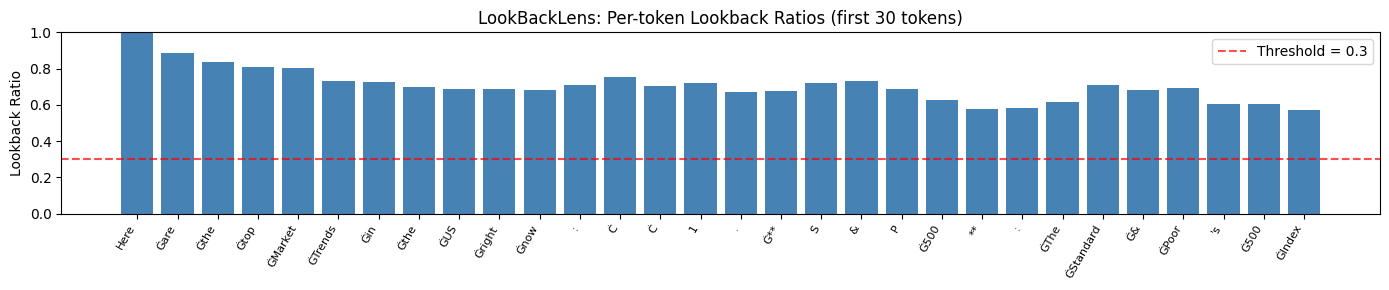

Red bars (ratio < 0.3) = token is mainly attending to prior generated text → potential hallucination signal.


In [125]:
# Visualise lookback ratios for the first sample
tokens_plot = [r["token"] for r in ratios[:30]]
ratio_vals = [r["lookback_ratio"] for r in ratios[:30]]

fig, ax = plt.subplots(figsize=(14, 3))
colors = ["tomato" if v < 0.3 else "steelblue" for v in ratio_vals]
ax.bar(range(len(tokens_plot)), ratio_vals, color=colors)
ax.axhline(0.3, color="red", linestyle="--", alpha=0.7, label="Threshold = 0.3")
ax.set_xticks(range(len(tokens_plot)))
ax.set_xticklabels(tokens_plot, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Lookback Ratio")
ax.set_title("LookBackLens: Per-token Lookback Ratios (first 30 tokens)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()
print("Red bars (ratio < 0.3) = token is mainly attending to prior generated text → potential hallucination signal.")

### 3.2 Batch evaluation

We evaluate LookBackLens on the same shared `eval_df` benchmark (clean + 3 corruption types)
with ground-truth labels.  Lookback-ratio features are extracted per sample; then both a
threshold classifier and a logistic-regression classifier are compared against the labels.

In [126]:
# ── Feature extraction: train set ─────────────────────────────────────────────
lbl_train_feats = []
for _, item in tqdm(train_df.iterrows(), total=len(train_df), desc="LookBackLens train"):
    context_input = f"Question: {item['query']}\nContext: {item['context']}"
    try:
        ratios = compute_lookback_ratios(
            lbl_model, lbl_tokenizer,
            context=context_input,
            answer=item["output"],
        )
        feats = aggregate_lookback_features(ratios)
    except Exception:
        feats = {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0}
    lbl_train_feats.append(feats)

print(f"Train feature extraction complete ({len(lbl_train_feats)} samples).")

# ── Feature extraction: test set ──────────────────────────────────────────────
lbl_raw_results = []
lbl_features = []

for _, item in tqdm(test_df.iterrows(), total=len(test_df), desc="LookBackLens test"):
    context_input = f"Question: {item['query']}\nContext: {item['context']}"
    try:
        ratios = compute_lookback_ratios(
            lbl_model, lbl_tokenizer,
            context=context_input,
            answer=item["output"],
        )
        feats = aggregate_lookback_features(ratios)
    except Exception:
        ratios = []
        feats = {"mean_ratio": 0.5, "min_ratio": 0.5, "frac_low": 0.0, "std_ratio": 0.0}

    lbl_raw_results.append({
        "query": item["query"][:60] + "...",
        "label": item["label"],
        "corruption_type": item["corruption_type"],
        "ratios": ratios,
    })
    lbl_features.append(feats)

print(f"Test feature extraction complete ({len(lbl_features)} samples).")

LookBackLens train: 100%|██████████| 3308/3308 [03:18<00:00, 16.71it/s]


Train feature extraction complete (3308 samples).


LookBackLens test: 100%|██████████| 828/828 [00:48<00:00, 16.94it/s]

Test feature extraction complete (828 samples).


In [127]:
# ── Threshold classifier evaluated against ground-truth labels ────────────────
THRESHOLD = 0.3

lbl_results = []
for raw, feats in zip(lbl_raw_results, lbl_features):
    mean_r = feats["mean_ratio"]
    lbl_results.append({
        "query": raw["query"],
        "label": raw["label"],
        "corruption_type": raw["corruption_type"],
        "predicted_hallucination_threshold": int(mean_r < THRESHOLD),
        "mean_lookback_ratio": mean_r,
        "min_lookback_ratio": feats["min_ratio"],
        "frac_low_ratio": feats.get("frac_low", feats.get("frac_low_03", 0.0)),
        "std_lookback_ratio": feats["std_ratio"],
    })

df_lbl = pd.DataFrame(lbl_results)
y_true_lbl = df_lbl["label"].values
y_pred_lbl = df_lbl["predicted_hallucination_threshold"].values

print(f"LookBackLens (threshold={THRESHOLD}) on {len(df_lbl)} samples:")
print(f"  Accuracy  : {accuracy_score(y_true_lbl, y_pred_lbl):.3f}")
print(f"  Precision : {precision_score(y_true_lbl, y_pred_lbl, zero_division=0):.3f}")
print(f"  Recall    : {recall_score(y_true_lbl, y_pred_lbl, zero_division=0):.3f}")
print(f"  F1        : {f1_score(y_true_lbl, y_pred_lbl, zero_division=0):.3f}")
print(f"  Mean lookback ratio: {np.mean([r['mean_lookback_ratio'] for r in lbl_results]):.4f}")

LookBackLens (threshold=0.3) on 828 samples:
  Accuracy  : 0.540
  Precision : 0.000
  Recall    : 0.000
  F1        : 0.000
  Mean lookback ratio: 0.6317


In [128]:
# ── Logistic Regression: train on train set, evaluate on test set ─────────────
X_train_lbl = np.array([
    [f["mean_ratio"], f["min_ratio"],
     f.get("frac_low", f.get("frac_low_03", 0.0)),
     f["std_ratio"]]
    for f in lbl_train_feats
])
X_test_lbl = np.array([
    [f["mean_ratio"], f["min_ratio"],
     f.get("frac_low", f.get("frac_low_03", 0.0)),
     f["std_ratio"]]
    for f in lbl_features
])
y_lbl_train = train_df["label"].to_numpy()
y_lbl_test  = test_df["label"].to_numpy()

lbl_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=seed)),
])
lbl_clf.fit(X_train_lbl, y_lbl_train)

y_pred_lr = lbl_clf.predict(X_test_lbl)
lbl_score  = lbl_clf.predict_proba(X_test_lbl)[:, 1]

print(f"LookBackLens LogReg — train={len(X_train_lbl)}, test={len(X_test_lbl)}:")
print(f"  Test Accuracy  : {accuracy_score(y_lbl_test, y_pred_lr):.3f}")
print(f"  Test Precision : {precision_score(y_lbl_test, y_pred_lr, zero_division=0):.3f}")
print(f"  Test Recall    : {recall_score(y_lbl_test, y_pred_lr, zero_division=0):.3f}")
print(f"  Test F1        : {f1_score(y_lbl_test, y_pred_lr, zero_division=0):.3f}")
coef = lbl_clf["clf"].coef_[0]
print(f"  Coefficients   : mean_ratio={coef[0]:.3f}, min_ratio={coef[1]:.3f}, "
      f"frac_low={coef[2]:.3f}, std_ratio={coef[3]:.3f}")

df_lbl["predicted_hallucination_logreg"] = y_pred_lr
df_lbl["lbl_score"] = lbl_score

LookBackLens LogReg — train=3308, test=828:
  Test Accuracy  : 0.506
  Test Precision : 0.476
  Test Recall    : 0.714
  Test F1        : 0.571
  Coefficients   : mean_ratio=-0.256, min_ratio=0.101, frac_low=0.038, std_ratio=-0.092


In [129]:
print("=== LookBackLens — Metrics by Corruption Type ===")
for ctype, sub in df_lbl.groupby("corruption_type"):
    yt = sub["label"].values
    yp = sub["predicted_hallucination_threshold"].values
    print(
        f"  {ctype:<28} "
        f"acc={accuracy_score(yt, yp):.3f}  "
        f"prec={precision_score(yt, yp, zero_division=0):.3f}  "
        f"rec={recall_score(yt, yp, zero_division=0):.3f}  "
        f"f1={f1_score(yt, yp, zero_division=0):.3f}"
    )

display(df_lbl.head(10))
print("\nValue counts — predicted_hallucination_threshold:")
display(df_lbl["predicted_hallucination_threshold"].value_counts())

=== LookBackLens — Metrics by Corruption Type ===
  clean                        acc=1.000  prec=0.000  rec=0.000  f1=0.000
  missing_tool                 acc=0.580  prec=0.000  rec=0.000  f1=0.000
  overgeneration               acc=0.580  prec=0.000  rec=0.000  f1=0.000
  tool_output_contradiction    acc=0.000  prec=0.000  rec=0.000  f1=0.000


,query,label,corruption_type,predicted_hallucination_threshold,mean_lookback_ratio,min_lookback_ratio,frac_low_ratio,std_lookback_ratio,predicted_hallucination_logreg,lbl_score
0,It's fascinating how languages shape our commu...,0,clean,0,0.594948,0.372283,0.0,0.109732,1,0.500354
1,Could you please provide me with the current t...,0,clean,0,0.599117,0.396825,0.0,0.099062,1,0.522848
2,Given the volatile nature of the crypto market...,0,clean,0,0.584013,0.422570,0.0,0.102467,1,0.543427
3,Could you show me the latest Instagram posts f...,0,clean,0,0.591270,0.423962,0.0,0.109998,1,0.520995
4,"Oh, that's great to know. Now that the serious...",0,clean,0,0.650711,0.455068,0.0,0.110331,0,0.456778
5,Can you please provide the ROA ratio for the c...,0,clean,0,0.664848,0.516321,0.0,0.095435,0,0.486451
6,"Hey, could you get me a list of all the tags i...",0,clean,0,0.674410,0.550597,0.0,0.099940,0,0.477247
7,It's like a jungle out there and I'm just tryi...,0,clean,0,0.541527,0.331777,0.0,0.127297,1,0.520978
8,"Hey, I'm preparing for our next social media c...",0,clean,0,0.573108,0.362262,0.0,0.119285,1,0.506487
9,Could you provide me with the top players' sta...,0,clean,0,0.547655,0.363817,0.0,0.117828,1,0.541157



Value counts — predicted_hallucination_threshold:


predicted_hallucination_threshold
0    828
Name: count, dtype: int64

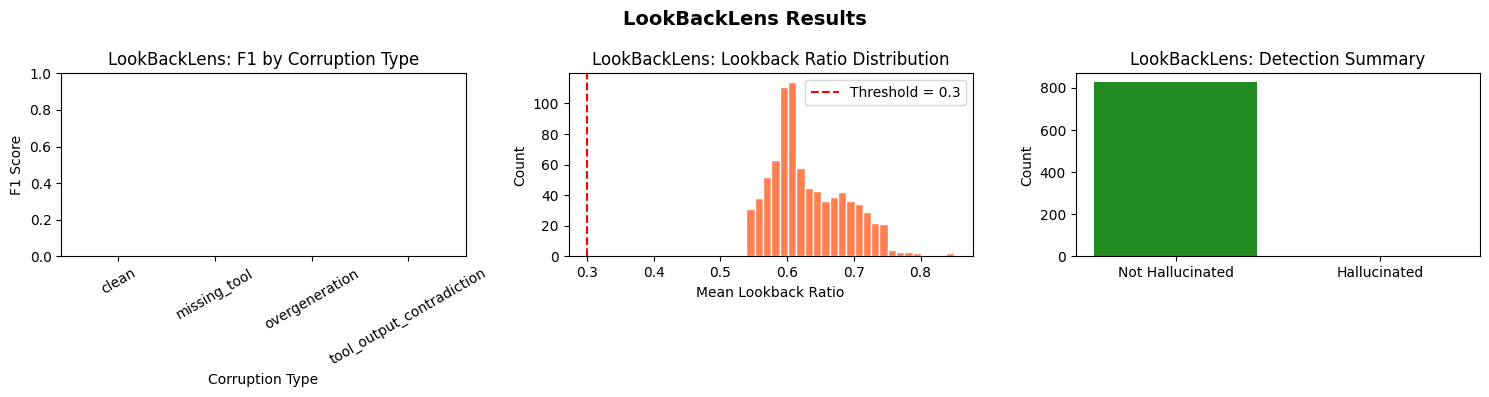

In [130]:
lbl_types = sorted(df_lbl["corruption_type"].unique())
f1_by_type_lbl = {
    ct: f1_score(
        df_lbl[df_lbl["corruption_type"] == ct]["label"],
        df_lbl[df_lbl["corruption_type"] == ct]["predicted_hallucination_threshold"],
        zero_division=0,
    )
    for ct in lbl_types
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(f1_by_type_lbl.keys(), f1_by_type_lbl.values(), color="coral")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Corruption Type")
axes[0].set_ylabel("F1 Score")
axes[0].set_title("LookBackLens: F1 by Corruption Type")
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(df_lbl["mean_lookback_ratio"], bins=25, color="coral", edgecolor="white")
axes[1].axvline(THRESHOLD, color="red", linestyle="--", label=f"Threshold = {THRESHOLD}")
axes[1].set_xlabel("Mean Lookback Ratio")
axes[1].set_ylabel("Count")
axes[1].set_title("LookBackLens: Lookback Ratio Distribution")
axes[1].legend()

counts_lbl = df_lbl["predicted_hallucination_threshold"].value_counts()
axes[2].bar(
    ["Not Hallucinated", "Hallucinated"],
    [counts_lbl.get(0, 0), counts_lbl.get(1, 0)],
    color=["forestgreen", "tomato"],
)
axes[2].set_ylabel("Count")
axes[2].set_title("LookBackLens: Detection Summary")

plt.suptitle("LookBackLens Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Side-by-Side Comparison

Both methods are evaluated on the same shared `eval_df` benchmark (clean + 3 corruption types)
using ground-truth `hallucination_labels`.  Metrics reported: Accuracy, Precision, Recall, F1.

Corruption types:
- **tool_output_contradiction** — output contradicts the tool's returned data
- **overgeneration** — model adds facts not present in the tool output
- **missing_tool** — model claims to use a tool that was never called

In [131]:
# Both df_lettuce and df_lbl are evaluated on the same test_df rows (same order)
comparison = pd.DataFrame({
    "query":                   df_lettuce["query"].values,
    "label":                   df_lettuce["label"].values,
    "corruption_type":         df_lettuce["corruption_type"].values,
    "LettuceDetect_flag":      df_lettuce["predicted_hallucination"].values,
    "LettuceDetect_score":     df_lettuce["lettuce_score"].values,
    "LookBackLens_flag":       df_lbl["predicted_hallucination_logreg"].values,
    "LookBackLens_score":      df_lbl["lbl_score"].values,
    "LookBackLens_mean_ratio": df_lbl["mean_lookback_ratio"].values,
})

y_true_c = comparison["label"].values
for method, col in [("LettuceDetect (LogReg)", "LettuceDetect_flag"),
                    ("LookBackLens  (LogReg)", "LookBackLens_flag")]:
    yp = comparison[col].values
    n  = len(comparison)
    print(f"\n{method} (n={n}):")
    print(f"  Accuracy  : {accuracy_score(y_true_c, yp):.3f}")
    print(f"  Precision : {precision_score(y_true_c, yp, zero_division=0):.3f}")
    print(f"  Recall    : {recall_score(y_true_c, yp, zero_division=0):.3f}")
    print(f"  F1        : {f1_score(y_true_c, yp, zero_division=0):.3f}")

n_eval     = len(comparison)
both_flag  = ((comparison["LettuceDetect_flag"] == 1) & (comparison["LookBackLens_flag"] == 1)).sum()
either_flag = ((comparison["LettuceDetect_flag"] == 1) | (comparison["LookBackLens_flag"] == 1)).sum()
agree_no   = ((comparison["LettuceDetect_flag"] == 0) & (comparison["LookBackLens_flag"] == 0)).sum()
print(f"\n=== Agreement Statistics (n={n_eval}) ===")
print(f"Both methods flag hallucination : {both_flag} ({both_flag / n_eval:.1%})")
print(f"At least one method flags        : {either_flag} ({either_flag / n_eval:.1%})")
print(f"Both agree: NOT hallucinated     : {agree_no} ({agree_no / n_eval:.1%})")

display(comparison.head(15))


LettuceDetect (LogReg) (n=828):
  Accuracy  : 0.460
  Precision : 0.460
  Recall    : 1.000
  F1        : 0.630

LookBackLens  (LogReg) (n=828):
  Accuracy  : 0.506
  Precision : 0.476
  Recall    : 0.714
  F1        : 0.571

=== Agreement Statistics (n=828) ===
Both methods flag hallucination : 572 (69.1%)
At least one method flags        : 828 (100.0%)
Both agree: NOT hallucinated     : 0 (0.0%)


,query,label,corruption_type,LettuceDetect_flag,LettuceDetect_score,LookBackLens_flag,LookBackLens_score,LookBackLens_mean_ratio
0,It's fascinating how languages shape our commu...,0,clean,1,0.511185,1,0.500354,0.594948
1,Could you please provide me with the current t...,0,clean,1,0.511185,1,0.522848,0.599117
2,Given the volatile nature of the crypto market...,0,clean,1,0.511185,1,0.543427,0.584013
3,Could you show me the latest Instagram posts f...,0,clean,1,0.511185,1,0.520995,0.591270
4,"Oh, that's great to know. Now that the serious...",0,clean,1,0.511185,0,0.456778,0.650711
5,Can you please provide the ROA ratio for the c...,0,clean,1,0.511185,0,0.486451,0.664848
6,"Hey, could you get me a list of all the tags i...",0,clean,1,0.511185,0,0.477247,0.674410
7,It's like a jungle out there and I'm just tryi...,0,clean,1,0.511185,1,0.520978,0.541527
8,"Hey, I'm preparing for our next social media c...",0,clean,1,0.511185,1,0.506487,0.573108
9,Could you provide me with the top players' sta...,0,clean,1,0.511185,1,0.541157,0.547655


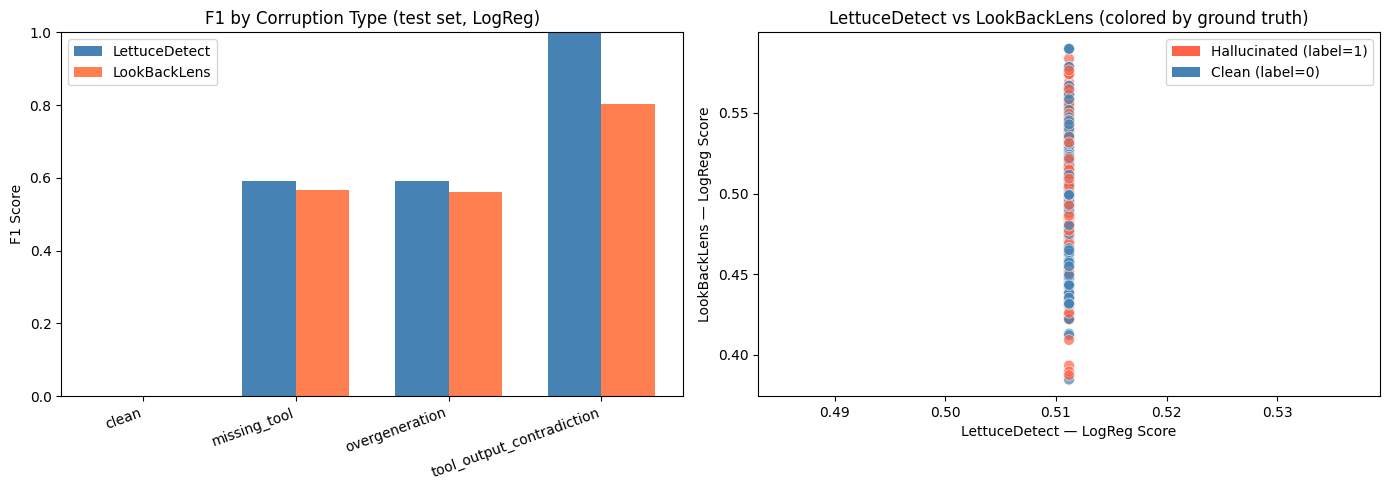

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar: F1 by corruption type for both methods
all_types = sorted(comparison["corruption_type"].unique())
lettuce_f1s, lbl_f1s = [], []
for ct in all_types:
    sub = comparison[comparison["corruption_type"] == ct]
    lettuce_f1s.append(f1_score(sub["label"], sub["LettuceDetect_flag"], zero_division=0))
    lbl_f1s.append(f1_score(sub["label"], sub["LookBackLens_flag"], zero_division=0))

x = np.arange(len(all_types))
w = 0.35
axes[0].bar(x - w / 2, lettuce_f1s, w, label="LettuceDetect", color="steelblue")
axes[0].bar(x + w / 2, lbl_f1s,     w, label="LookBackLens",  color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_types, rotation=20, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("F1 Score")
axes[0].set_title("F1 by Corruption Type (test set, LogReg)")
axes[0].legend()

# Scatter: LogReg scores for both methods, colored by ground-truth label
colors = ["tomato" if lb == 1 else "steelblue" for lb in comparison["label"]]
axes[1].scatter(
    comparison["LettuceDetect_score"],
    comparison["LookBackLens_score"],
    c=colors, alpha=0.7, edgecolors="white", linewidths=0.5, s=60,
)
axes[1].set_xlabel("LettuceDetect — LogReg Score")
axes[1].set_ylabel("LookBackLens — LogReg Score")
axes[1].set_title("LettuceDetect vs LookBackLens (colored by ground truth)")

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor="tomato",    label="Hallucinated (label=1)"),
    Patch(facecolor="steelblue", label="Clean (label=0)"),
])

plt.tight_layout()
plt.show()

In [134]:
y_true_s = comparison["label"].values

summary = pd.DataFrame({
    "Method":    ["LettuceDetect", "LookBackLens"],
    "Classifier": ["LogisticRegression (train/test split)",
                   "LogisticRegression (train/test split)"],
    "Backbone":  [
        "ModernBERT (lettucedect-base-modernbert-en-v1)",
        "GPT-2 (demo; paper uses Llama-2-7B)",
    ],
    "Train Samples": [len(train_df), len(train_df)],
    "Test Samples":  [len(test_df),  len(test_df)],
    "Accuracy": [
        f"{accuracy_score(y_true_s, comparison['LettuceDetect_flag'].values):.3f}",
        f"{accuracy_score(y_true_s, comparison['LookBackLens_flag'].values):.3f}",
    ],
    "Precision": [
        f"{precision_score(y_true_s, comparison['LettuceDetect_flag'].values, zero_division=0):.3f}",
        f"{precision_score(y_true_s, comparison['LookBackLens_flag'].values, zero_division=0):.3f}",
    ],
    "Recall": [
        f"{recall_score(y_true_s, comparison['LettuceDetect_flag'].values, zero_division=0):.3f}",
        f"{recall_score(y_true_s, comparison['LookBackLens_flag'].values, zero_division=0):.3f}",
    ],
    "F1": [
        f"{f1_score(y_true_s, comparison['LettuceDetect_flag'].values, zero_division=0):.3f}",
        f"{f1_score(y_true_s, comparison['LookBackLens_flag'].values, zero_division=0):.3f}",
    ],
})
display(summary)

print(f'''
Split: train_test_split(example_ids, test_size=0.2, random_state={seed})
  Train: {len(train_df)} rows  |  Test: {len(test_df)} rows  |  No example_id leakage

CORRUPTION_FILES from datasets/:
  tool_output_contradiction  - output contradicts the tool's returned data
  overgeneration             - model adds facts not present in the tool output
  missing_tool               - model claims to use a tool that was never called

Classifiers (both): Pipeline([StandardScaler, LogisticRegression(max_iter=1000)])
  LettuceDetect features : max span score, number of hallucinated spans
  LookBackLens features  : mean_ratio, min_ratio, frac_low, std_ratio
''')

,Method,Classifier,Backbone,Train Samples,Test Samples,Accuracy,Precision,Recall,F1
0,LettuceDetect,LogisticRegression (train/test split),ModernBERT (lettucedect-base-modernbert-en-v1),3308,828,0.460,0.460,1.000,0.630
1,LookBackLens,LogisticRegression (train/test split),GPT-2 (demo; paper uses Llama-2-7B),3308,828,0.506,0.476,0.714,0.571



Split: train_test_split(example_ids, test_size=0.2, random_state=1241)
  Train: 3308 rows  |  Test: 828 rows  |  No example_id leakage

CORRUPTION_FILES from datasets/:
  tool_output_contradiction  - output contradicts the tool's returned data
  overgeneration             - model adds facts not present in the tool output
  missing_tool               - model claims to use a tool that was never called

Classifiers (both): Pipeline([StandardScaler, LogisticRegression(max_iter=1000)])
  LettuceDetect features : max span score, number of hallucinated spans
  LookBackLens features  : mean_ratio, min_ratio, frac_low, std_ratio

